In [1]:
import numpy as np

ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

print(ket0 / 2 + ket1 / 2)

[[0.5]
 [0.5]]


In [2]:
M1 = np.array([[1, 1], [0, 0]])   # How numpy works : Divide all elements by 2 → [[0.5, 0.5], [0, 0]]
M2 = np.array([[1, 0], [0, 1]])
M = M1 / 2 + M2 / 2
print(M)

[[1.  0.5]
 [0.  0.5]]


In [3]:
print(M1 @ ket1) # @ Matrix multiplication
print(M1 @ M2)
print(M @ M)

[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


In [4]:
from qiskit.visualization import array_to_latex # Import

display(array_to_latex(M1 @ ket1)) #Displaying cleanly with LaTeX
display(array_to_latex(M1 @ M2))
display(array_to_latex(M @ M))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [5]:
from qiskit.quantum_info import Statevector # both importing
from numpy import sqrt #root

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3]) # j means imaginary unit
w = Statevector([1 / 3, 2 / 3])

display(u.draw("text")) # Displaying the precise values
display(u.draw("latex")) # I prefer this one!!
print(u.draw("latex_source")) # I dont like this.

display(u.is_valid()) # Dont forget to sqare each to get the probability of each state and check if they add up to 1.
display(w.is_valid())  # 1/9 + 4/9 = 5/9 != 1.
display(v.draw("latex"))

outcome, state = v.measure() # half half chance to get 0 or 1, and the state will collapse to the corresponding state.
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


True

False

<IPython.core.display.Latex object>

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

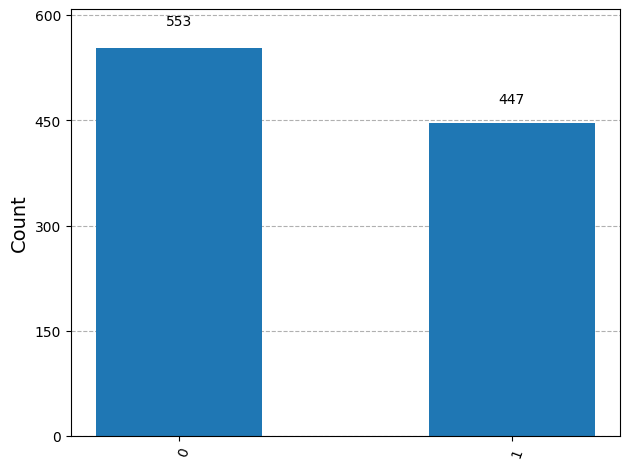

In [6]:
from qiskit.visualization import plot_histogram # Importing the histogram plotting function

statistics = v.sample_counts(1000) # Run 1000 times
plot_histogram(statistics) # Draw

In [7]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]]) #Pauli-y gate
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]]) # Hadamard gate
S = Operator([[1, 0], [0, 1.0j]]) # S gate
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]]) # T gate

display(T.draw("latex"))

v = Statevector([1, 0]) #Why using evolve instead of @? Because we want to apply the gate to the state, //
                        #not just do matrix multiplication. evolve will handle the state transformation correctly.

v = v.evolve(H) # Apply Hadamard (H) gate to create an equal superposition state
v = v.evolve(T) # Apply T gate to rotate the phase by 45 degrees
v = v.evolve(H) # Apply H gate again to mix the state
v = v.evolve(S) # Apply S gate to rotate the phase by 90 degrees
v = v.evolve(Y) # Finally, apply Pauli-Y gate to flip the state completely

display(v.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

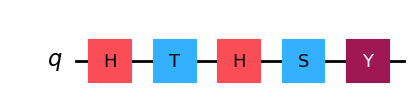

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

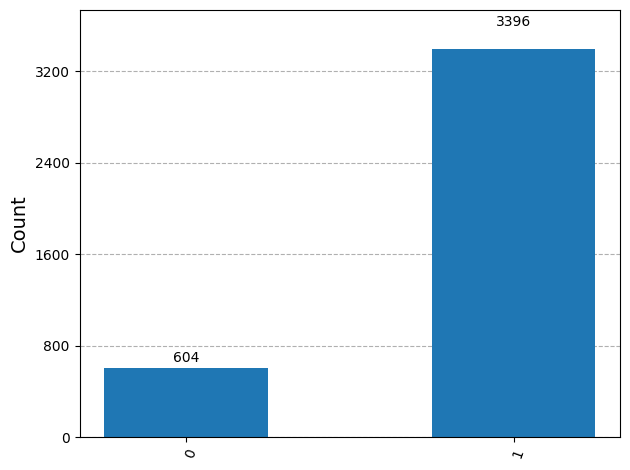

In [8]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1) # Create a quantum circuit with 1 qubit

circuit.h(0) # Hadamard gate creates an equal superposition state (|0> + |1>) / sqrt(2)
circuit.t(0) # T gate rotates the phase of the |1> state by 45 degrees, resulting in (|0> + e^(i*pi/4)|1>) / sqrt(2)
circuit.h(0) # Applying H again will mix the state, creating a new superposition that depends on the previous phase shift.
circuit.s(0) # S gate rotates the phase of the |1> state by 90 degrees, further modifying the superposition state.
circuit.y(0) # Pauli-Y gate flips the state completely, transforming |0> to |1> and |1> to |0>, but also adds a phase factor of i to the |1> state.

display(circuit.draw(output="mpl")) # Blue is T / S gate, Purple is Pauli gate, Red / orange is Hadamard.

display(Operator.from_circuit(circuit).draw("latex")) # Circuit to operator, @, right to left, reversed order → Y @ S @ H @ T @ H

ket0 = Statevector([1, 0])
v = ket0.evolve(circuit) # Impressive! I can directly evolve the state with the circuit, and it will apply all the gates in the correct order.
display(v.draw("latex"))

statistics = v.sample_counts(4000) # 4000 samples
display(plot_histogram(statistics)) # Histogram